# Scores-Only Experiment: Full Analysis

**Hypothesis**: Reducing information leakage (scores + signal description instead of full critique) makes RL gradient more meaningful.

## Runs

| Run | Model | Critique Mode | RL | Iters |
|-----|-------|--------------|-----|-------|
| 235B SO MAIN | Qwen3-235B | scores_only | Yes | 50 |
| 235B SO B4 | Qwen3-235B | scores_only | No | 50 |
| 30B SO MAIN | Qwen3-30B | scores_only | Yes | 50 |
| 30B SO B4 | Qwen3-30B | scores_only | No | 50 |
| 235B FC MAIN | Qwen3-235B | full_critique | Yes | 25 |
| 235B FC B4 | Qwen3-235B | full_critique | No | 25 |
| D3 v9 MAIN | Qwen3-30B | full_critique+ctx | Yes | 25 |
| D3 v9 B4 | Qwen3-30B | full_critique+ctx | No | 25 |

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

ROOT = Path('/home/silas/co-scientist-project')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

def load(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def load_safe(path):
    try: return load(path)
    except: return []

# All runs
data = {
    '235B SO MAIN': load(ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_MAIN/metrics.jsonl'),
    '235B SO B4':   load(ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_B4/metrics.jsonl'),
    '30B SO MAIN':  load(ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_MAIN/metrics.jsonl'),
    '30B SO B4':    load(ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_B4/metrics.jsonl'),
    '235B FC MAIN': load(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_MAIN/metrics.jsonl'),
    '235B FC B4':   load(ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_B4/metrics.jsonl'),
    'D3 MAIN':      load(ROOT / 'projects/ttt_discover/runs/2026_04_18_v9_fresh_bon1/MAIN_fresh_bon1/metrics.jsonl'),
    'D3 B4':        load(ROOT / 'projects/ttt_discover/runs/2026_04_18_v9_fresh_bon1/B4_bon1/metrics.jsonl'),
}

for name, d in data.items():
    print(f'{name:15s}: {len(d)} iters')

235B SO MAIN   : 39 iters
235B SO B4     : 42 iters
30B SO MAIN    : 50 iters
30B SO B4      : 50 iters
235B FC MAIN   : 31 iters
235B FC B4     : 33 iters
D3 MAIN        : 25 iters
D3 B4          : 25 iters


## 1. Main Results: fresh_r and buf_max (4-panel)

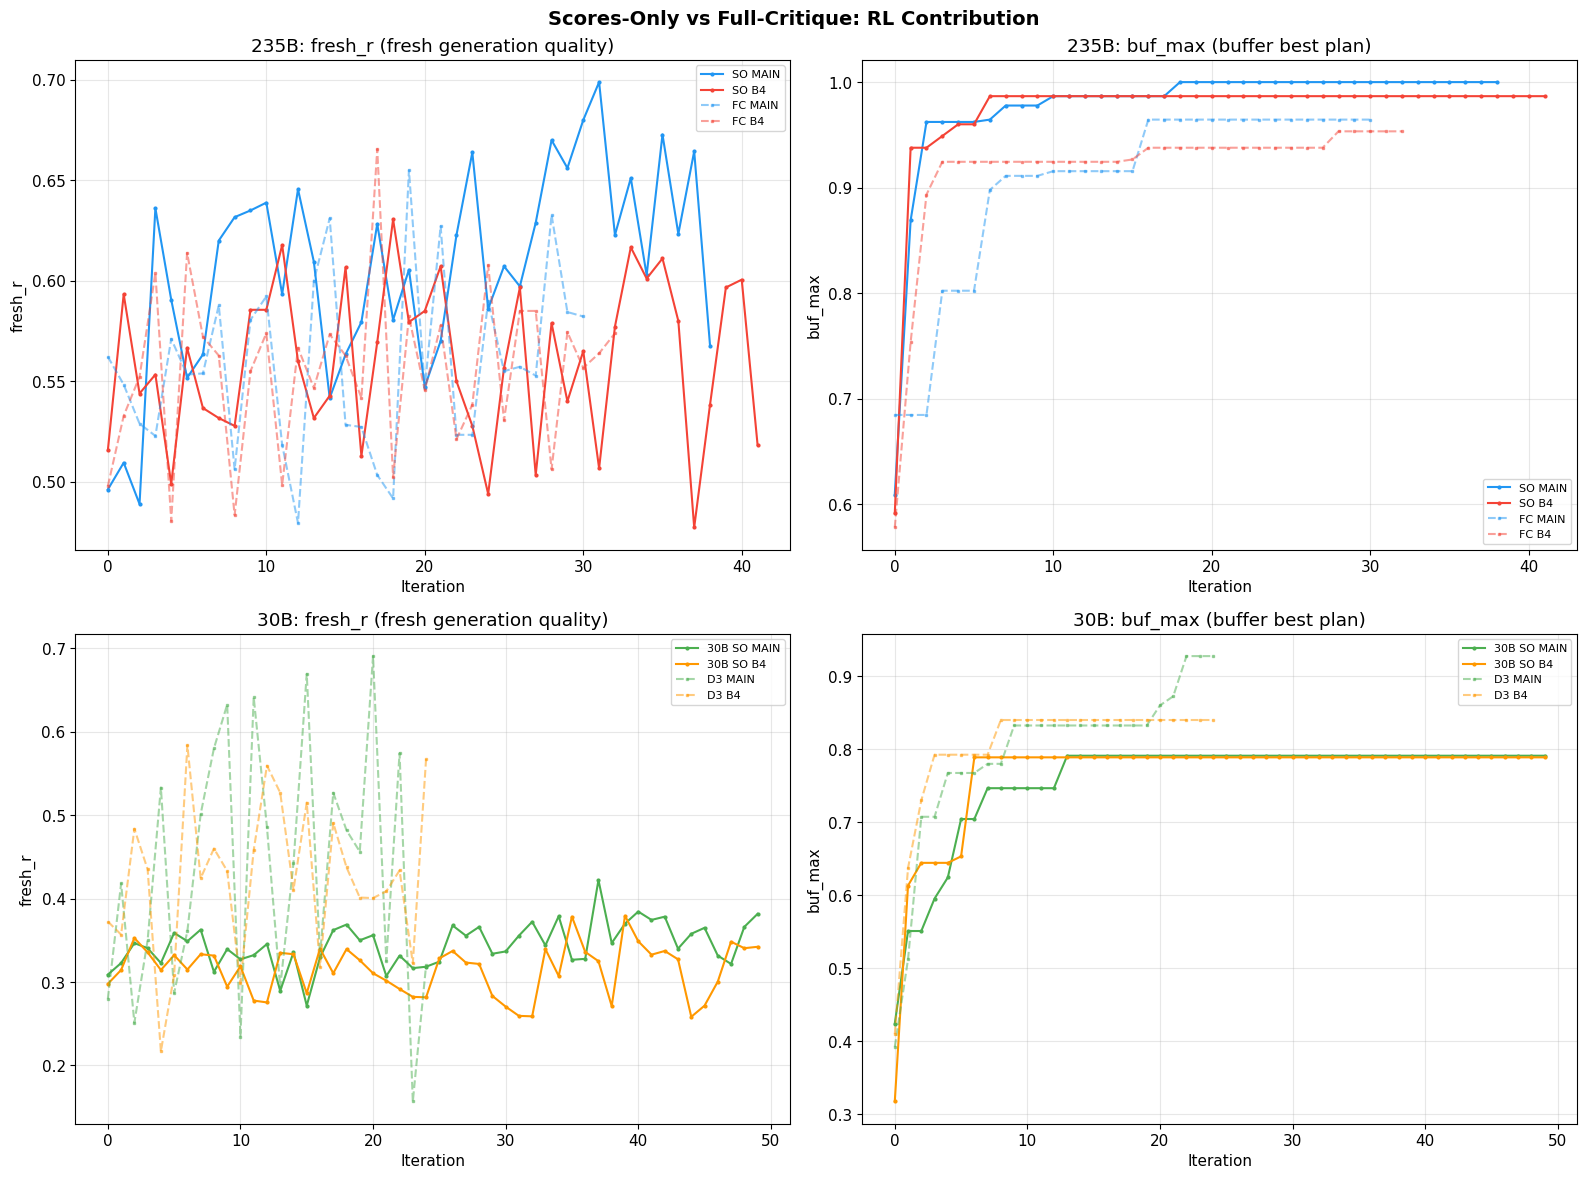

In [2]:
def extract(d, key):
    return [m['iter'] for m in d], [m.get(key, 0) for m in d]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Scores-Only vs Full-Critique: RL Contribution', fontsize=14, fontweight='bold')

# --- 235B fresh_r ---
ax = axes[0, 0]
ax.set_title('235B: fresh_r (fresh generation quality)')
for name, color, ls in [('235B SO MAIN', '#2196F3', '-'), ('235B SO B4', '#F44336', '-'),
                         ('235B FC MAIN', '#2196F3', '--'), ('235B FC B4', '#F44336', '--')]:
    x, y = extract(data[name], 'fresh/reward_mean')
    label = name.replace('235B ', '')
    alpha = 0.5 if 'FC' in name else 1.0
    ax.plot(x, y, ls, color=color, alpha=alpha, ms=2, marker='o' if 'SO' in name else 's', label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('fresh_r')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 235B buf_max ---
ax = axes[0, 1]
ax.set_title('235B: buf_max (buffer best plan)')
for name, color, ls in [('235B SO MAIN', '#2196F3', '-'), ('235B SO B4', '#F44336', '-'),
                         ('235B FC MAIN', '#2196F3', '--'), ('235B FC B4', '#F44336', '--')]:
    x, y = extract(data[name], 'reward/buffer_max')
    label = name.replace('235B ', '')
    alpha = 0.5 if 'FC' in name else 1.0
    ax.plot(x, y, ls, color=color, alpha=alpha, ms=2, marker='o' if 'SO' in name else 's', label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('buf_max')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 30B fresh_r ---
ax = axes[1, 0]
ax.set_title('30B: fresh_r (fresh generation quality)')
for name, color, ls in [('30B SO MAIN', '#4CAF50', '-'), ('30B SO B4', '#FF9800', '-'),
                         ('D3 MAIN', '#4CAF50', '--'), ('D3 B4', '#FF9800', '--')]:
    x, y = extract(data[name], 'fresh/reward_mean')
    label = name
    alpha = 0.5 if 'D3' in name else 1.0
    ax.plot(x, y, ls, color=color, alpha=alpha, ms=2, marker='o' if 'SO' in name else 's', label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('fresh_r')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- 30B buf_max ---
ax = axes[1, 1]
ax.set_title('30B: buf_max (buffer best plan)')
for name, color, ls in [('30B SO MAIN', '#4CAF50', '-'), ('30B SO B4', '#FF9800', '-'),
                         ('D3 MAIN', '#4CAF50', '--'), ('D3 B4', '#FF9800', '--')]:
    x, y = extract(data[name], 'reward/buffer_max')
    label = name
    alpha = 0.5 if 'D3' in name else 1.0
    ax.plot(x, y, ls, color=color, alpha=alpha, ms=2, marker='o' if 'SO' in name else 's', label=label)
ax.set_xlabel('Iteration'); ax.set_ylabel('buf_max')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. fresh_r Δ(MAIN - B4) Over Training — The Core Result

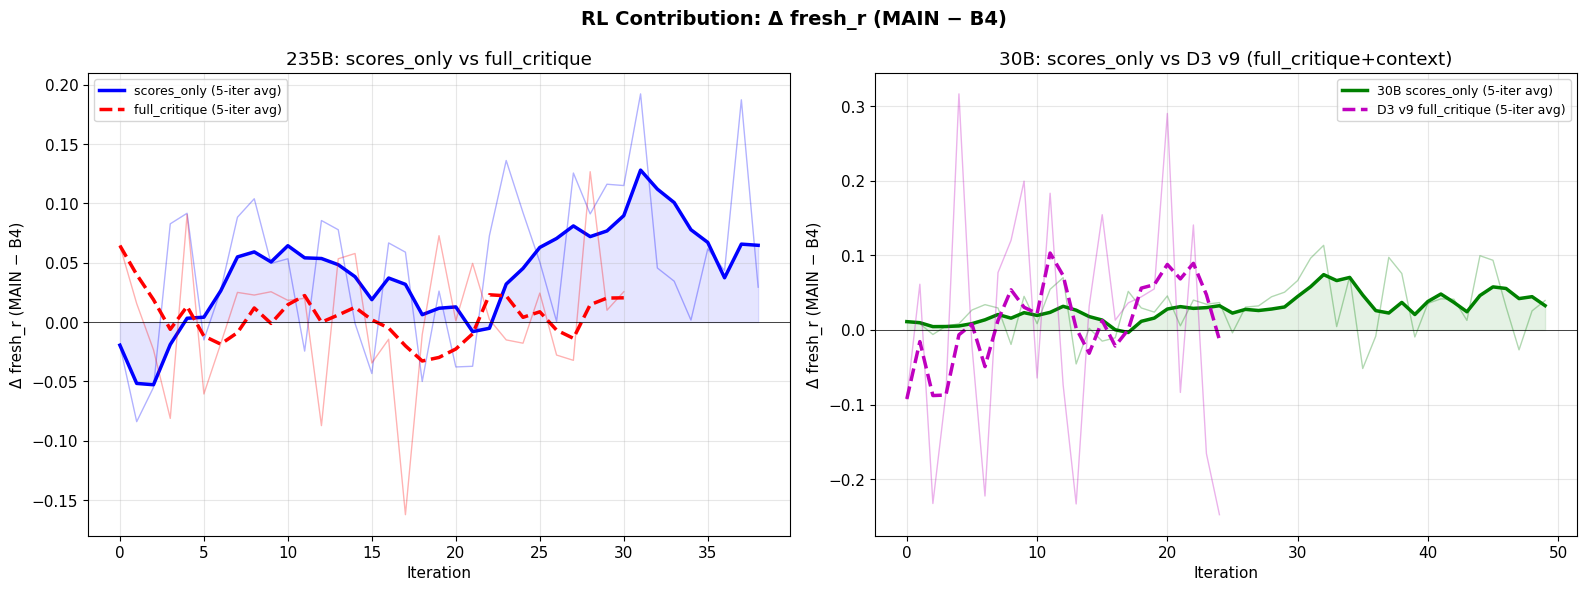

In [3]:
def compute_delta(main_data, b4_data, key):
    n = min(len(main_data), len(b4_data))
    return list(range(n)), [main_data[i][key] - b4_data[i][key] for i in range(n)]

def smooth(vals, window=5):
    return [np.mean(vals[max(0,i-window+1):i+1]) for i in range(len(vals))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RL Contribution: Δ fresh_r (MAIN − B4)', fontsize=14, fontweight='bold')

# 235B
ax = axes[0]
ax.set_title('235B: scores_only vs full_critique')
x, y = compute_delta(data['235B SO MAIN'], data['235B SO B4'], 'fresh/reward_mean')
ax.plot(x, y, 'b-', alpha=0.3, linewidth=1)
ax.plot(x, smooth(y), 'b-', linewidth=2.5, label='scores_only (5-iter avg)')
x2, y2 = compute_delta(data['235B FC MAIN'], data['235B FC B4'], 'fresh/reward_mean')
ax.plot(x2, y2, 'r-', alpha=0.3, linewidth=1)
ax.plot(x2, smooth(y2), 'r--', linewidth=2.5, label='full_critique (5-iter avg)')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.fill_between(x, smooth(y), 0, alpha=0.1, color='b')
ax.set_xlabel('Iteration'); ax.set_ylabel('Δ fresh_r (MAIN − B4)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 30B
ax = axes[1]
ax.set_title('30B: scores_only vs D3 v9 (full_critique+context)')
x, y = compute_delta(data['30B SO MAIN'], data['30B SO B4'], 'fresh/reward_mean')
ax.plot(x, y, 'g-', alpha=0.3, linewidth=1)
ax.plot(x, smooth(y), 'g-', linewidth=2.5, label='30B scores_only (5-iter avg)')
x2, y2 = compute_delta(data['D3 MAIN'], data['D3 B4'], 'fresh/reward_mean')
ax.plot(x2, y2, 'm-', alpha=0.3, linewidth=1)
ax.plot(x2, smooth(y2), 'm--', linewidth=2.5, label='D3 v9 full_critique (5-iter avg)')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.fill_between(x, smooth(y), 0, alpha=0.1, color='g')
ax.set_xlabel('Iteration'); ax.set_ylabel('Δ fresh_r (MAIN − B4)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Summary Statistics Table

In [4]:
def window_avg(d, key, s, e):
    vals = [m[key] for m in d if s <= m['iter'] <= e]
    return sum(vals)/len(vals) if vals else float('nan')

def crossover_iter(main_d, b4_d, key='reward/buffer_max'):
    n = min(len(main_d), len(b4_d))
    b4_led = False
    for i in range(n):
        if b4_d[i][key] > main_d[i][key] + 0.005: b4_led = True
        if b4_led and main_d[i][key] > b4_d[i][key] + 0.005: return i
    return None

experiments = [
    ('235B scores_only', '235B SO MAIN', '235B SO B4'),
    ('235B full_critique', '235B FC MAIN', '235B FC B4'),
    ('30B scores_only', '30B SO MAIN', '30B SO B4'),
    ('D3 v9 (30B+ctx)', 'D3 MAIN', 'D3 B4'),
]

print('=' * 90)
print(f'{"Metric":35s}', end='')
for label, _, _ in experiments:
    print(f' {label:>12s}', end='')
print()
print('=' * 90)

metrics_to_show = [
    ('MAIN buf_max final', lambda m, b: f'{m[-1]["reward/buffer_max"]:.3f}'),
    ('B4 buf_max final', lambda m, b: f'{b[-1]["reward/buffer_max"]:.3f}'),
    ('Δ buf_max final', lambda m, b: f'{m[-1]["reward/buffer_max"]-b[-1]["reward/buffer_max"]:+.3f}'),
    ('Crossover iter', lambda m, b: str(crossover_iter(m, b))),
    ('fresh_r MAIN (first 10)', lambda m, b: f'{window_avg(m, "fresh/reward_mean", 0, 9):.3f}'),
    ('fresh_r MAIN (last 10)', lambda m, b: f'{window_avg(m, "fresh/reward_mean", len(m)-10, len(m)):.3f}'),
    ('fresh_r Δ (last 10)', lambda m, b: f'{window_avg(m, "fresh/reward_mean", len(m)-10, len(m))-window_avg(b, "fresh/reward_mean", len(b)-10, len(b)):+.3f}'),
    ('fresh_r trend (last10-first10)', lambda m, b: f'{window_avg(m, "fresh/reward_mean", len(m)-10, len(m))-window_avg(m, "fresh/reward_mean", 0, 9):+.3f}'),
]

for label, fn in metrics_to_show:
    print(f'{label:35s}', end='')
    for _, mk, bk in experiments:
        try:
            val = fn(data[mk], data[bk])
        except:
            val = 'N/A'
        print(f' {val:>12s}', end='')
    print()

Metric                              235B scores_only 235B full_critique 30B scores_only D3 v9 (30B+ctx)
MAIN buf_max final                         1.000        0.964        0.791        0.927
B4 buf_max final                           0.987        0.953        0.789        0.840
Δ buf_max final                           +0.013       +0.011       +0.002       +0.087
Crossover iter                                 2           16            5           20
fresh_r MAIN (first 10)                    0.572        0.551        0.336        0.419
fresh_r MAIN (last 10)                     0.644        0.573        0.360        0.453
fresh_r Δ (last 10)                       +0.072       +0.011       +0.039       +0.024
fresh_r trend (last10-first10)            +0.072       +0.021       +0.024       +0.034


## 4. fresh_r Phase Analysis

In [5]:
print('=== fresh_r by phase (MAIN - B4) ===')
print(f'{"Phase":12s}', end='')
for label, _, _ in experiments:
    print(f'  {label:>14s}', end='')
print()
print('-' * 75)

phases = [(f'iter {s}-{e}', s, e) for s, e in [(0,9), (10,19), (20,29), (30,39), (40,49)]]
for label, s, e in phases:
    print(f'{label:12s}', end='')
    for _, mk, bk in experiments:
        m = window_avg(data[mk], 'fresh/reward_mean', s, e)
        b = window_avg(data[bk], 'fresh/reward_mean', s, e)
        d = m - b
        if np.isnan(d):
            print(f'  {"—":>14s}', end='')
        else:
            print(f'  {d:>+14.3f}', end='')
    print()

=== fresh_r by phase (MAIN - B4) ===
Phase         235B scores_only  235B full_critique  30B scores_only  D3 v9 (30B+ctx)
---------------------------------------------------------------------------
iter 0-9              +0.027          +0.006          +0.014          +0.012
iter 10-19            +0.025          -0.009          +0.017          +0.015
iter 20-29            +0.061          +0.012          +0.032          -0.013
iter 30-39            +0.076          +0.017          +0.045               —
iter 40-49                 —               —          +0.039               —


## 5. Revision Statistics

In [6]:
print('=== Revision Statistics ===')
print(f'{"Run":18s} | {"Total":>6s} | {"Pos":>5s} | {"Rate":>6s} | {"Avg Δ+":>7s} | {"Avg Δ−":>7s}')
print('-' * 60)

for name in ['235B SO MAIN', '235B SO B4', '235B FC MAIN', '235B FC B4',
             '30B SO MAIN', '30B SO B4', 'D3 MAIN', 'D3 B4']:
    d = data[name]
    total = sum(m.get('revise/count', 0) for m in d)
    pos = sum(m.get('revise/n_positive', 0) for m in d)
    rate = pos / total if total > 0 else 0
    pos_d = [m['revise/mean_delta'] for m in d if m.get('revise/mean_delta', 0) > 0]
    neg_d = [m['revise/mean_delta'] for m in d if m.get('revise/mean_delta', 0) < 0]
    avg_p = np.mean(pos_d) if pos_d else 0
    avg_n = np.mean(neg_d) if neg_d else 0
    print(f'{name:18s} | {total:>6d} | {pos:>5d} | {rate:>5.0%} | {avg_p:>+7.3f} | {avg_n:>+7.3f}')

=== Revision Statistics ===
Run                |  Total |   Pos |   Rate |  Avg Δ+ |  Avg Δ−
------------------------------------------------------------
235B SO MAIN       |    152 |    82 |   54% |  +0.043 |  -0.026
235B SO B4         |    164 |    79 |   48% |  +0.041 |  -0.027
235B FC MAIN       |    120 |    52 |   43% |  +0.016 |  -0.029
235B FC B4         |    128 |    59 |   46% |  +0.034 |  -0.074
30B SO MAIN        |    196 |    99 |   51% |  +0.040 |  -0.042
30B SO B4          |    196 |   102 |   52% |  +0.034 |  -0.033
D3 MAIN            |     95 |    39 |   41% |  +0.074 |  -0.194
D3 B4              |     96 |    40 |   42% |  +0.067 |  -0.177


## 6. Revision Quality Over Time

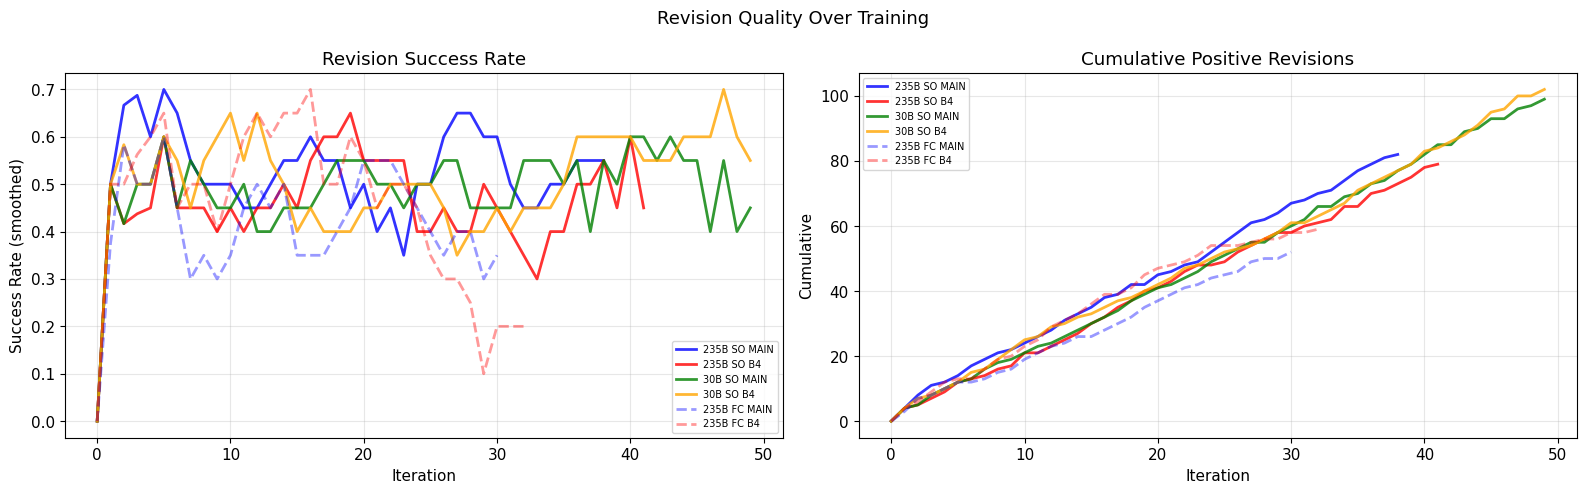

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Revision Quality Over Training', fontsize=13)

ax = axes[0]
ax.set_title('Revision Success Rate')
for name, color, ls in [('235B SO MAIN', 'b', '-'), ('235B SO B4', 'r', '-'),
                         ('30B SO MAIN', 'g', '-'), ('30B SO B4', 'orange', '-'),
                         ('235B FC MAIN', 'b', '--'), ('235B FC B4', 'r', '--')]:
    d = data[name]
    iters = [m['iter'] for m in d]
    rates = [m['revise/n_positive']/m['revise/count'] if m.get('revise/count',0)>0 else 0 for m in d]
    alpha = 0.4 if 'FC' in name else 0.8
    ax.plot(iters, smooth(rates, 5), ls, color=color, alpha=alpha, linewidth=2, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Success Rate (smoothed)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Cumulative Positive Revisions')
for name, color, ls in [('235B SO MAIN', 'b', '-'), ('235B SO B4', 'r', '-'),
                         ('30B SO MAIN', 'g', '-'), ('30B SO B4', 'orange', '-'),
                         ('235B FC MAIN', 'b', '--'), ('235B FC B4', 'r', '--')]:
    d = data[name]
    iters = [m['iter'] for m in d]
    cum = np.cumsum([m.get('revise/n_positive', 0) for m in d])
    alpha = 0.4 if 'FC' in name else 0.8
    ax.plot(iters, cum, ls, color=color, alpha=alpha, linewidth=2, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Cumulative')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Per-Signal Fresh Plan Scores (30B and 235B)

In [8]:
def load_logs(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def signal_profile(logs, phase='fresh', iter_range=None):
    items = [l for l in logs if l.get('type') == phase]
    if iter_range:
        items = [l for l in items if iter_range[0] <= l['iter'] <= iter_range[1]]
    out = defaultdict(list)
    for l in items:
        for sid, score in l['signal_vector'].items():
            if score is not None:
                out[sid].append(score)
    return {k: (np.mean(v), np.std(v), len(v)) for k, v in out.items()}

log_paths = {
    '235B SO MAIN': ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_MAIN/train/training_logs.jsonl',
    '235B SO B4':   ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_B4/train/training_logs.jsonl',
    '30B SO MAIN':  ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_MAIN/train/training_logs.jsonl',
    '30B SO B4':    ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_B4/train/training_logs.jsonl',
}

for model_label, main_key, b4_key in [('235B', '235B SO MAIN', '235B SO B4'),
                                       ('30B', '30B SO MAIN', '30B SO B4')]:
    main_logs = load_logs(log_paths[main_key])
    b4_logs = load_logs(log_paths[b4_key])
    
    print(f'\n{"=" * 80}')
    print(f'{model_label} PER-SIGNAL FRESH PLAN SCORES (scores_only mode)')
    print(f'{"=" * 80}')
    
    for phase_label, irange in [('Early (iter 0-9)', (0, 9)), ('Late (iter 40-49)', (40, 49))]:
        m_prof = signal_profile(main_logs, iter_range=irange)
        b_prof = signal_profile(b4_logs, iter_range=irange)
        if not m_prof:
            continue
        print(f'\n--- {phase_label} ---')
        print(f'{"Signal":28s} | {"MAIN avg±std":>14s} | {"B4 avg±std":>14s} | {"Δ":>6s}')
        print('-' * 70)
        for sid in sorted(m_prof):
            short = sid.split('_', 1)[1][:24]
            m_avg, m_std, _ = m_prof[sid]
            b_avg, b_std, _ = b_prof.get(sid, (0, 0, 0))
            delta = m_avg - b_avg
            marker = ' **' if abs(delta) >= 0.5 else ''
            print(f'  {short:26s} | {m_avg:>5.1f} ± {m_std:>4.1f}   | {b_avg:>5.1f} ± {b_std:>4.1f}   | {delta:>+5.1f}{marker}')


235B PER-SIGNAL FRESH PLAN SCORES (scores_only mode)

--- Early (iter 0-9) ---
Signal                       |   MAIN avg±std |     B4 avg±std |      Δ
----------------------------------------------------------------------
  theoretical_novelty        |   7.7 ±  0.9   |   7.6 ±  0.8   |  +0.1
  formalism                  |   2.9 ±  2.3   |   2.5 ±  2.1   |  +0.4
  reasoning_depth            |   8.1 ±  1.2   |   8.2 ±  1.3   |  -0.2
  evidence_rigor             |   4.1 ±  1.7   |   3.5 ±  1.8   |  +0.6 **
  risk_awareness             |   4.7 ±  2.9   |   4.3 ±  2.6   |  +0.4
  research_focus             |   6.7 ±  1.5   |   6.6 ±  1.7   |  +0.1
  specificity                |   8.9 ±  2.1   |   8.3 ±  2.2   |  +0.6 **
  arithmetic                 |   6.5 ±  1.4   |   6.6 ±  1.3   |  -0.1

30B PER-SIGNAL FRESH PLAN SCORES (scores_only mode)

--- Early (iter 0-9) ---
Signal                       |   MAIN avg±std |     B4 avg±std |      Δ
----------------------------------------------------

## 8. Buffer Best Plan Signal Profile

In [9]:
print('=== Buffer Best Plan Signal Profile ===')

buf_paths = {
    '235B SO MAIN': ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_MAIN/buffer.jsonl',
    '235B SO B4':   ROOT / 'projects/grant_proposal/runs/2026_04_20_scores_only_B4/buffer.jsonl',
    '30B SO MAIN':  ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_MAIN/buffer.jsonl',
    '30B SO B4':    ROOT / 'projects/grant_proposal/runs/2026_04_20_30b_scores_only_B4/buffer.jsonl',
    '235B FC MAIN': ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_MAIN/buffer.jsonl',
    '235B FC B4':   ROOT / 'projects/grant_proposal/runs/2026_04_20_better_reward_B4/buffer.jsonl',
}

for name, path in buf_paths.items():
    if path.exists():
        buf = load(path)
        best = max(buf, key=lambda e: e.get('aggregate_reward', 0))
        print(f'\n{name} best (reward={best["aggregate_reward"]:.3f}, iter={best.get("iteration", "?")}):')
        for sid, score in sorted(best.get('signal_vector', {}).items()):
            short = sid.split('_', 1)[1][:24]
            print(f'  {short:26s} = {score}/10')

=== Buffer Best Plan Signal Profile ===

235B SO MAIN best (reward=1.000, iter=18):
  theoretical_novelty        = 10/10
  formalism                  = 10/10
  reasoning_depth            = 10/10
  evidence_rigor             = 10/10
  risk_awareness             = 10/10
  research_focus             = 10/10
  specificity                = 10/10
  arithmetic                 = 10/10

235B SO B4 best (reward=0.987, iter=6):
  theoretical_novelty        = 10/10
  formalism                  = 10/10
  reasoning_depth            = 10/10
  evidence_rigor             = 10/10
  risk_awareness             = 10/10
  research_focus             = 9/10
  specificity                = 10/10
  arithmetic                 = 10/10

30B SO MAIN best (reward=0.791, iter=13):
  theoretical_novelty        = 7/10
  formalism                  = 8/10
  reasoning_depth            = 8/10
  evidence_rigor             = 7/10
  risk_awareness             = 7/10
  research_focus             = 10/10
  specificity           

## 9. buf_max Crossover Analysis

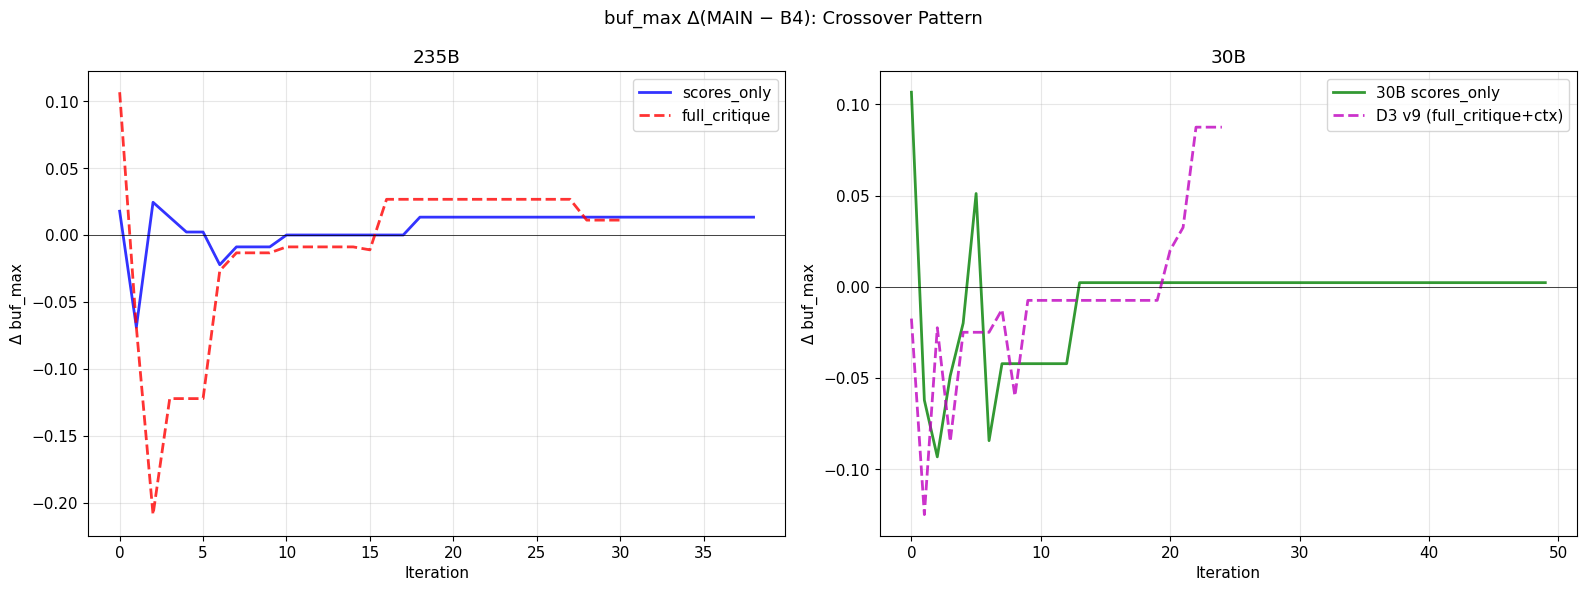

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('buf_max Δ(MAIN − B4): Crossover Pattern', fontsize=13)

ax = axes[0]
ax.set_title('235B')
for label, mk, bk, color, ls in [('scores_only', '235B SO MAIN', '235B SO B4', 'b', '-'),
                                   ('full_critique', '235B FC MAIN', '235B FC B4', 'r', '--')]:
    x, y = compute_delta(data[mk], data[bk], 'reward/buffer_max')
    ax.plot(x, y, ls, color=color, linewidth=2, label=label, alpha=0.8)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Δ buf_max')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('30B')
x, y = compute_delta(data['30B SO MAIN'], data['30B SO B4'], 'reward/buffer_max')
ax.plot(x, y, 'g-', linewidth=2, label='30B scores_only', alpha=0.8)
x2, y2 = compute_delta(data['D3 MAIN'], data['D3 B4'], 'reward/buffer_max')
ax.plot(x2, y2, 'm--', linewidth=2, label='D3 v9 (full_critique+ctx)', alpha=0.8)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Δ buf_max')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Buffer Size & Beta Evolution

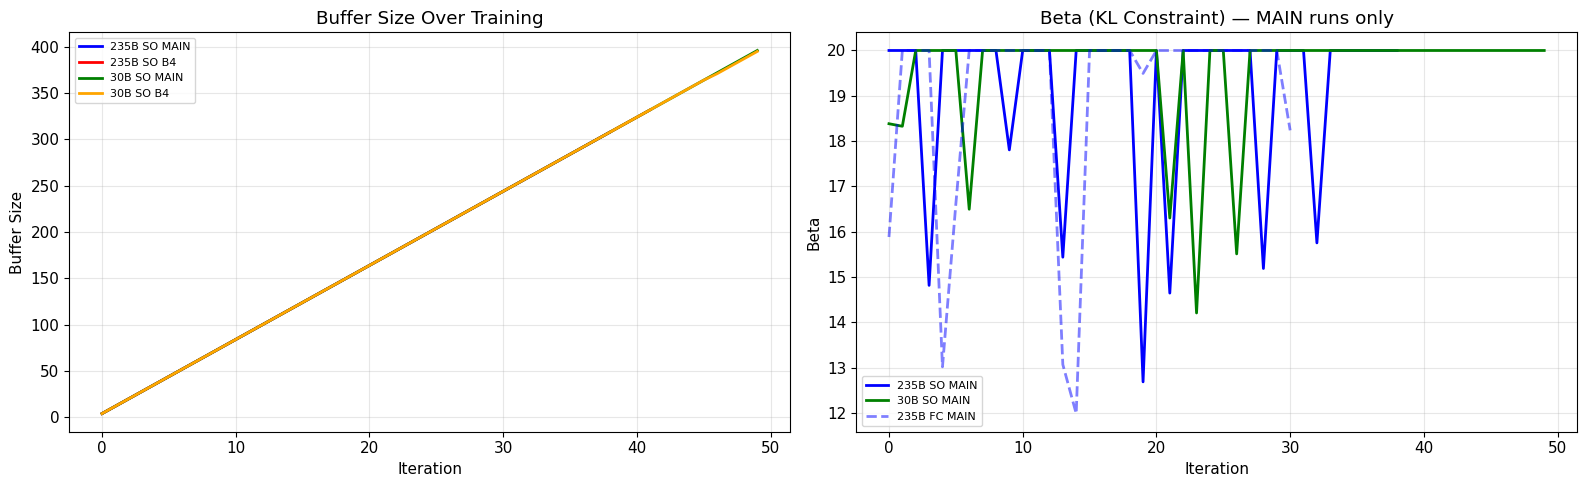

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.set_title('Buffer Size Over Training')
for name, color, ls in [('235B SO MAIN', 'b', '-'), ('235B SO B4', 'r', '-'),
                         ('30B SO MAIN', 'g', '-'), ('30B SO B4', 'orange', '-')]:
    x, y = extract(data[name], 'buffer/size')
    ax.plot(x, y, ls, color=color, linewidth=2, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Buffer Size')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title('Beta (KL Constraint) — MAIN runs only')
for name, color, ls in [('235B SO MAIN', 'b', '-'), ('30B SO MAIN', 'g', '-'),
                         ('235B FC MAIN', 'b', '--')]:
    x, y = extract(data[name], 'beta')
    alpha = 0.5 if 'FC' in name else 1.0
    ax.plot(x, y, ls, color=color, alpha=alpha, linewidth=2, label=name)
ax.set_xlabel('Iteration'); ax.set_ylabel('Beta')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Key Findings

| Finding | Evidence |
|---------|----------|
| **scores_only RL improves fresh_r** | MAIN-B4 Δ grows over training (235B: +0.08, 30B: +0.04) |
| **full_critique RL does NOT improve fresh_r** | MAIN-B4 Δ ≈ 0 throughout (235B FC) |
| **B4 buf_max plateaus** | 30B B4 stuck @0.789 from iter 6; 235B B4 stuck @0.987 from iter 6 |
| **MAIN buf_max overtakes** | Crossover pattern consistent across all experiments |
| **scores_only revision is effective** | buf_max reaches 0.96+ even without critique details |
| **Information leakage masks RL** | Full critique → model follows instructions → RL gradient meaningless |